In [1]:
import numpy as np
#import ray
import matplotlib.pyplot as plt
import pythtb
import wannierberri as wberri
from wannierberri.system import System_PythTB
from pythtb import tb_model
from wannierberri.evaluate_k import evaluate_k_path
from hall_ps.hall_positional_shift import HallPositionalShift

/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-09 00:58:46,379	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
print(wberri.__version__)

26.4.3


# WannierBerri PythTB

In [3]:
def model_ferroaxial_pythtb(mu=0.0, t=1.0, tp=1.0, Delta=1.0, t2=0.5, t3=1.0, a=1.0, c=1.0):

    a_latt = a*np.sqrt(3)
    lat = np.array([[a_latt,-0,0], [-a_latt/2, a_latt*np.sqrt(3)/2, 0], [0, 0, c]])
    orb = np.array([[0, 0, 0] , [1/3, 2/3, 0]])  
    
    #lattice = pythtb.Lattice(lat_vecs=lat, orb_vecs=orb, periodic_dirs=[0, 1, 2])
    #my_model = pythtb.TBModel(lattice)

    my_model = tb_model(3, 3, lat, orb)
    my_model.set_onsite([Delta - mu, -Delta - mu])

    
    for shift in [[0,0,0], [0, -1,0], [-1,-1,0]]:
        # nearest neighbor hoppings in-plane (t)
        my_model.set_hop(t, 0, 1, shift)
        # Vertical Hoppings (tpz)
        if tp != 0:
            for z in [1, -1]:
                my_model.set_hop( tp, 0, 1, [shift[0], shift[1],  z])


    if t3 != 0:
        # Third Neighbor Hoppings (tp)
        my_model.set_hop( t3, 1, 0, [ 2,  2,  0]) 
        my_model.set_hop( t3, 1, 0, [ 0, -1,  0])
        my_model.set_hop( t3, 1, 0, [-1,  1,  0])
        my_model.set_hop(-t3, 0, 1, [ 1,  1,  0]) 
        my_model.set_hop(-t3, 0, 1, [-2, -1,  0])
        my_model.set_hop(-t3, 0, 1, [ 0, -2,  0])


    # The tc term (Diagonal Hoppings)
    if t2 != 0:
        for shift in [[0,1,0], [1,0,0], [1,1,0]]: # Skipping [0,0,0] for diagonal
            for i in range(2):
                my_model.set_hop(t2, i, i, shift)

    return my_model

In [4]:
parameters1 = dict(mu=0.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.0, a=1.0, c=1.0)
model1 = model_ferroaxial_pythtb(**parameters1)
system1 = System_PythTB(model1)
system1.set_pointgroup(symmetry_gen=["C3z", "TimeReversal"])

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (23, 2, 2)
Real-space lattice:
 [[ 1.73205081  0.          0.        ]
 [-0.8660254   1.5         0.        ]
 [ 0.          0.          1.        ]]
Number of wannier functions: 2
Number of R points: 23
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully


/tmp/ipykernel_44024/1596711675.py:10: DeprecationWarning: pythtb.tb_model is deprecated and will be removed in a future release. Use TBModel instead.
  my_model = tb_model(3, 3, lat, orb)


Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x7b203c78fb00>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x7b2040bc3a40> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x7b203c78fb00>
All calculators are compatible
Symmetrization switched off for Path
Grid is regular
The set of k points is a Path() with 996 points and labels {0: 'G', 199: 'M', 398: 'K', 597: 'G', 796: 'A', 995: 'K'}
generating K_list
Done 
Done, sum of weights:996.0

########

/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/run_grid.py:207: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    996 K-points on   1 processes:     0.5318 ; per K-point          0.0005 ; proc-sec per K-point          0.0005
time1 =  2.384185791015625e-07
Totally processed 996 K-points 
run() finished
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x7b20335130e0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x7b210c297230> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x7b20335130e0>
All calculators are compatible
Symmetrization swit

/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/result/tabresult.py:367: RuntimeWarning: Mean of empty slice
  x_ticks_positions = [x_ticks_positions[b1:b2].mean() for b1, b2 in zip(borders, borders[1:])]
/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/result/tabresult.py:367: RuntimeWarning: Mean of empty slice
  x_ticks_positions = [x_ticks_positions[b1:b2].mean() for b1, b2 in zip(borders, borders[1:])]
/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


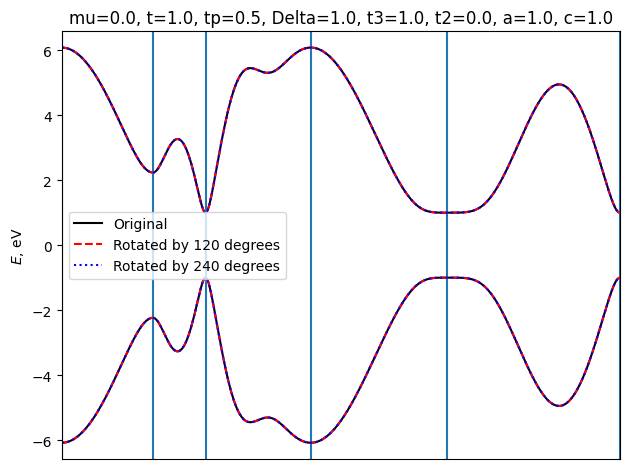

In [5]:
path=wberri.Path.from_nodes(system1,
        nodes=[
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.5, 0.0, 0.0],  # M: Center of the rectangular side face
                [1/3, 1/3, 0.0],   # K: Corner of the hexagonal face
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.0, 0.0, 0.5],  # A: Center of the top face (k_z = pi/c)
                [1/3, 1/3, 0.0]   # K: Corner of the hexagonal face
            ],
             labels=["G", "M", "K", "G", "A", "K"],
             nk = 200 )  

bands = evaluate_k_path(system1, path=path)

recip_latt = system1.recip_lattice
kp_cart = np.array(path.get_kpoints_cart())

rot_mat = np.array([[np.cos(np.radians(120)), -np.sin(np.radians(120)), 0],
                    [np.sin(np.radians(120)),  np.cos(np.radians(120)), 0],
                    [0, 0, 1]])

kp_cart_rot =  kp_cart @ rot_mat.T
kp_cart_rot2 = kp_cart @ rot_mat.T @ rot_mat.T

kp_latt_rot = kp_cart_rot @ np.linalg.inv(recip_latt)
kp_latt_rot2 = kp_cart_rot2 @ np.linalg.inv(recip_latt)

path_rot = wberri.Path(recip_lattice=recip_latt, k_list=kp_latt_rot)
path_rot2 = wberri.Path(recip_lattice=recip_latt, k_list=kp_latt_rot2)

bands_rot = evaluate_k_path(system1, path=path_rot)
bands_rot2 = evaluate_k_path(system1, path=path_rot2)

bands.plot_path_fat(path, close_fig=False, show_fig=False, label="Original", linecolor='k')
bands_rot.plot_path_fat(path_rot, linecolor='r', kwargs_line={'linestyle':'--'},label="Rotated by 120 degrees", show_fig=False, close_fig=False)
bands_rot2.plot_path_fat(path_rot2, linecolor='b', kwargs_line={'linestyle':':'},label="Rotated by 240 degrees", show_fig=False, close_fig=False)
plt.title(", ".join([f"{key}={value}" for key, value in parameters1.items()]))
plt.legend()
plt.tight_layout()
filename = "ferroaxial_bands" + "_".join([f"{key}={value:.3f}" for key, value in parameters1.items()]) + ".pdf"
plt.savefig(filename)
plt.show()


# Positional Shift

In [ ]:
tetra = True
Efermi = np.linspace(-8, +8, 1601)
grid = wberri.Grid(system, NKdiv=[16, 16, 16], NKFFT=[2, 2, 2])

calculators = {}
calculators["hall_positional_shift_morb"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"morb_part": True, 
                                                                                                            "external_terms":False},)
calculators["hall_positional_shift_metric"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"metric_part": True, 
                                                                                                              "external_terms":False},)

#ray.init(num_cpus=2)

result_run = wberri.run(system1,
        grid=grid,
        calculators = calculators,
        parallel=False,
        adpt_num_iter=50,
        fout_name='./output/ferroaxial-tb-TR-sym-tetra',
        restart=False,
        use_irred_kpt=True,
        symmetrize=True
        )

In [ ]:
import matplotlib as mpl

mpl.rcParams['lines.linestyle'] = '--'
mpl.rcParams['lines.linewidth'] = 0.5
mpl.rcParams['lines.color'] = 'gray'

ery = (-8.0, 8.0)

fig, ax = plt.subplots(1,3, figsize=(15,4), gridspec_kw={'width_ratios': [2, 1, 1]})

bands.plot_path_fat(path, iband=None, 
                                        mode="fatband", fatfactor=20, cut_k=False, close_fig=False, 
                                        show_fig=False, axes = ax[0], label = "Wannier",
                                        kwargs_line= {'linestyle' : '-', 'linewidth' : 1})

ax[0].set_ylabel(r'E-$\mathrm{E_f}$ (eV)')

for i in range(50, 51, 1):
    a = np.loadtxt(f"./output/ferroaxial-tb-TR-sym-tetra-hall_positional_shift_metric_iter-{i:04d}.dat")
    ax[1].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[1].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[1].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[1].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')      
    a = np.loadtxt(f"./output/ferroaxial-tb-TR-sym-tetra-hall_positional_shift_morb_iter-{i:04d}.dat")
    ax[2].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[2].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[2].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[2].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')     

ax[0].set_ylim(ery[0], ery[1])

ax[1].axhline(0, linestyle='--', color='red')
ax[1].legend(loc='upper left')
ax[1].set_ylim(ery[0], ery[1])
#ax[1].set_xlim(-500, 500)
ax[1].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$', fontsize=12)

ax[2].axhline(0, linestyle='--', color='red')
ax[2].legend(loc='upper right')
ax[2].set_ylim(ery[0], ery[1])
#ax[2].set_xlim(-40, 40)
ax[2].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{morb}$', fontsize=12)

plt.tight_layout()
plt.savefig("ferro_bands_cond_pos_C3z_TR.pdf")

# k-resolved

In [6]:
from wannierberri.formula.covariant import QuantumMetric_ab
from wannierberri.formula.covariant import DerQuantumMetric_ab_d
from hall_ps.hall_positional_shift import HallPositionalShift, PositionalShiftFormula

Efermi = np.linspace(-10, +10, 1601)

path = wberri.Path.from_nodes(system1,
        nodes=[
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.5, 0.0, 0.0],  # M: Center of the rectangular side face
                [1/3, 1/3, 0.0],   # K: Corner of the hexagonal face
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.0, 0.0, 0.5],  # A: Center of the top face (k_z = pi/c)
                [1/3, 1/3, 0.0]   # K: Corner of the hexagonal face
            ],
             labels=["G", "M", "K", "G", "A", "K"],
             nk = 100 )  

tabulator =wberri.calculators.TabulatorAll(
    {
        "energy": wberri.calculators.tabulate.Energy(),
        "g": wberri.calculators.tabulate.Tabulator(Formula=QuantumMetric_ab),
        "dg_dk": wberri.calculators.tabulate.Tabulator(Formula=DerQuantumMetric_ab_d),
        "pos_shift_morb": wberri.calculators.tabulate.Tabulator(Formula=PositionalShiftFormula, 
                                                                kwargs_formula={"morb_part": True, 
                                                                               "metric_part":False},
                                                                               ),
        "pos_shift_metric": wberri.calculators.tabulate.Tabulator(Formula=PositionalShiftFormula, 
                                                                kwargs_formula={"morb_part": False,
                                                                               "metric_part":True},),
        "Omega" : wberri.calculators.tabulate.BerryCurvature(),
        'pos_shift_calc' : HallPositionalShift(Efermi=Efermi, k_resolved=True, kwargs_formula={"morb_part": True, "external_terms": False})

    },
    mode="path"
)


result = wberri.run(
    system=system1,
    grid=path,
    calculators={"tab": tabulator},
)

Starting run()
Using the follwing calculators : 
############################################################

 'tab'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x7b2032772000>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "energy" : <wannierberri.calculators.tabulate.Energy object at 0x7b203c6806e0> : calculator not described

 "g" : <wannierberri.calculators.tabulate.Tabulator object at 0x7b203c6831d0> : calculator not described

 "dg_dk" : <wannierberri.calculators.tabulate.Tabulator object at 0x7b2031f45e80> : calculator not described

 "pos_shift_morb" : <wannierberri.calculators.tabulate.Tabulator object at 0x7b203293ab10> : calculator not described

 "pos_shift_metric" : <wannierberri.calculators.tabulate.Tabulator object at 0x7b2031e93e90> : calculator not described

 "Omega" : <wannierberri.calculators.tabulate.BerryCurvature object at 0x

/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/run_grid.py:207: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    496 K-points on   1 processes:     1.2945 ; per K-point          0.0026 ; proc-sec per K-point          0.0026
time1 =  4.76837158203125e-07
Totally processed 496 K-points 
run() finished


In [7]:
res_tab = result.results["tab"]
energy = res_tab.get_data("energy")   
print ("Energy shape:", energy.shape)
g = res_tab.get_data("g")         
print ("g shape:", g.shape)
dg_dk = res_tab.get_data("dg_dk") 
print ("dg_dk shape:", dg_dk.shape)
pos_shift_morb = res_tab.get_data("pos_shift_morb")  
print ("pos_shift_morb shape:", pos_shift_morb.shape)
pos_shift_metric = res_tab.get_data("pos_shift_metric") 
print ("pos_shift_metric shape:", pos_shift_metric.shape)
Omega = res_tab.get_data("Omega")        
print ("Omega shape:", Omega.shape)
pos_shift_calc = res_tab.get_data("pos_shift_calc")  
print ("pos_shift_calc shape:", pos_shift_calc.shape)

Energy shape: (496, 2)
g shape: (496, 2, 3, 3)
dg_dk shape: (496, 2, 3, 3, 3)
pos_shift_morb shape: (496, 2, 3, 3)
pos_shift_metric shape: (496, 2, 3, 3)
Omega shape: (496, 2, 3)
pos_shift_calc shape: (496, 2, 3, 3)


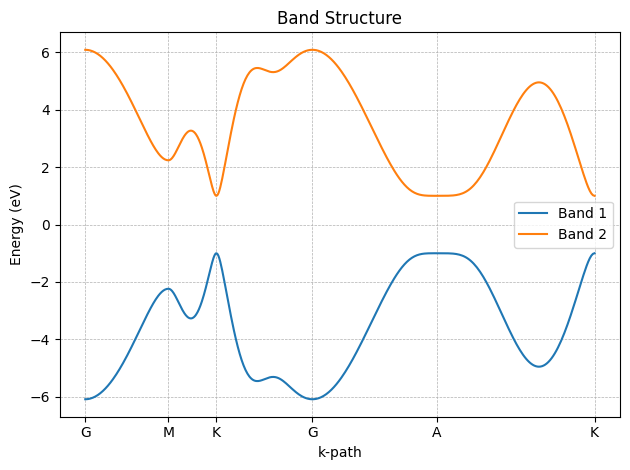

In [12]:
from matplotlib import pyplot as plt

kline = path.getKline()
plt.plot(kline, energy[:,0], label="Band 1")
plt.plot(kline, energy[:,1], label="Band 2")

x_ticks_labels = []
x_ticks_positions = []
for k, v in path.labels.items():
    x_ticks_labels.append(v)
    x_ticks_positions.append(kline[k])


plt.xticks(ticks=x_ticks_positions, labels=x_ticks_labels)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.title("Band Structure")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

In [14]:
print(path.labels)
print(tick_positions)

{0: 'G', 99: 'M', 198: 'K', 297: 'G', 396: 'A', 495: 'K'}
[ 0.          2.56564249  5.13128497  7.69692746 10.26256994 12.82821243]


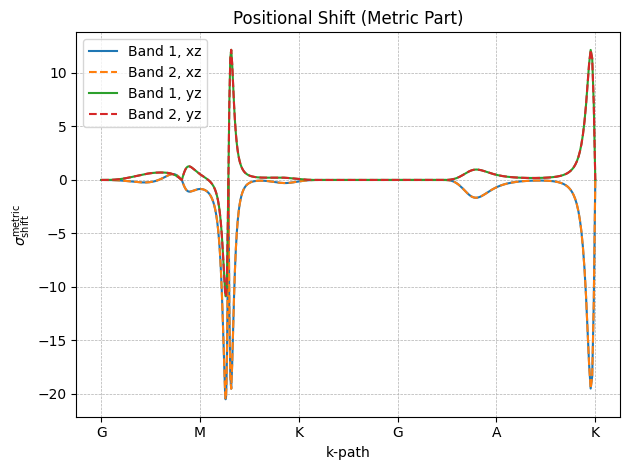

In [15]:
plt.plot(kline, pos_shift_metric[:,0,0,2], label="Band 1, xz")
plt.plot(kline, pos_shift_metric[:,1,0,2], label="Band 2, xz", linestyle='--')
plt.plot(kline, pos_shift_metric[:,0,1,2], label="Band 1, yz")
plt.plot(kline, pos_shift_metric[:,1,1,2], label="Band 2, yz", linestyle='--')

tick_positions = np.linspace(kline[0], kline[-1], len(path.labels))
plt.xticks(ticks=tick_positions, labels=path.labels.values())
plt.grid(True, which='both', linestyle='--', linewidth=0.5)    
plt.xlabel("k-path")
plt.ylabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$')
plt.title("Positional Shift (Metric Part)") 
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

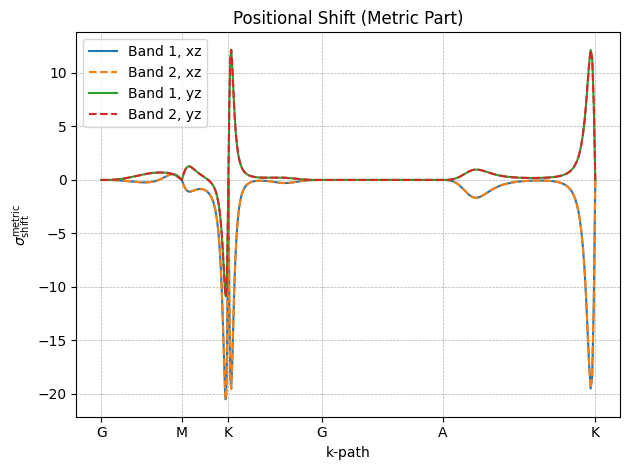

In [16]:
plt.plot(kline, pos_shift_metric[:,0,0,2], label="Band 1, xz")
plt.plot(kline, pos_shift_metric[:,1,0,2], label="Band 2, xz", linestyle='--')
plt.plot(kline, pos_shift_metric[:,0,1,2], label="Band 1, yz")
plt.plot(kline, pos_shift_metric[:,1,1,2], label="Band 2, yz", linestyle='--')

plt.xlabel("k-path")
plt.ylabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$')
plt.title("Positional Shift (Metric Part)") 
plt.xticks(ticks=x_ticks_positions, labels=x_ticks_labels)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend()
plt.tight_layout()
plt.show()
plt.close()

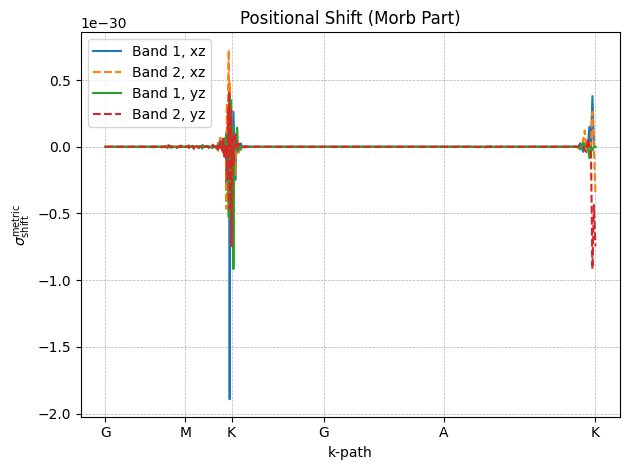

In [17]:
plt.plot(kline, pos_shift_morb[:,0,0,2], label="Band 1, xz")
plt.plot(kline, pos_shift_morb[:,1,0,2], label="Band 2, xz", linestyle='--')
plt.plot(kline, pos_shift_morb[:,0,1,2], label="Band 1, yz")
plt.plot(kline, pos_shift_morb[:,1,1,2], label="Band 2, yz", linestyle='--')
plt.xlabel("k-path")
plt.ylabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$')
plt.title("Positional Shift (Morb Part)")

plt.xticks(ticks=x_ticks_positions, labels=x_ticks_labels)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()
plt.close()